# 03 — Convert the trained dense model into an MoE, and keep training

**The trainer's ask.** *Train a Linear model and convert that into an MoE! Must show they continue to train and reduce loss.*

## Recipe: sparse upcycling

1. Take the **trained dense** checkpoint from notebook 01.
2. For every `moe_every`-th block, replace the MLP by `E` experts, each initialised as an **exact copy** of that MLP.
   Embeddings, attention, norms and the remaining dense MLPs are copied unchanged.
3. Add a freshly initialised, small-weight **router**.
4. Continue training with a fresh optimiser, a gentle LR re-warm-up and the load-balancing loss.

Because gates are renormalised over the selected experts, and all experts compute the same function, the converted model's output
equals the dense model's for any router. **Loss at the instant of conversion = loss of the dense model**, and
from there the model has `E×` the MLP capacity in the MoE layers to exploit.

To make the claim measurable we run two continuations from the *same* checkpoint on the *same* batches with the *same* LR schedule:

| run | what happens after step `dense_steps` |
|---|---|
| `dense_continue` | **control**: keep training the dense model |
| `moe_upcycled` | convert to MoE, then train |

In [1]:
import json
import math
import os
import sys
import time
import warnings

warnings.filterwarnings("ignore")
sys.path.insert(0, os.environ.get("MOE_SRC", os.path.abspath("../src")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from moe.analysis import make_decoder, make_encoder
from moe.config import get_config
from moe.data import load_dataset_tokens
from moe.model import GPT, GPTConfig, MoEMLP, param_report
from moe.runs import dense_config, flops_per_token, moe_config, train_config
from moe.trainer import load_history, load_model, lr_at, train
from moe.upcycle import max_logit_diff, upcycle
from moe.utils import (
    aim_repo,
    ckpt_dir,
    get_device,
    is_smoke,
    plot_style,
    results_dir,
    savefig,
    set_seed,
    work_root,
)
from moe.viz import color, ema, heatmap_load

plot_style()
X = get_config()
DEVICE = get_device()
torch.set_float32_matmul_precision("high")
set_seed(X.seed)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

print(
    f"torch {torch.__version__} | device = {DEVICE}"
    + (
        f" ({torch.cuda.get_device_name(0)}, {torch.cuda.get_device_properties(0).total_memory / 1e9:.0f} GB)"
        if DEVICE == "cuda"
        else ""
    )
)
print(f"preset = {X.name!r}   (override with MOE_PRESET=smoke|small|base)")
print(f"Aim repo : {aim_repo()}   -> browse with:  uv run aim up")
print()
print(pd.Series(X.to_dict(), name="value").to_string())

torch 2.6.0+cu124 | device = cuda:1
preset = 'base'   (override with MOE_PRESET=smoke|small|base)
Aim repo : /home/ravi.naik/learning/era/ERA/v5/session14/moe_experiments   -> browse with:  uv run aim up

name                    base
vocab_size             50304
block_size               512
n_layer                    8
n_head                     8
n_embd                   512
dropout                  0.0
bias                    True
n_experts                  8
top_k                      2
moe_every                  2
score_fn             softmax
lb_coef               0.0001
bias_update            0.001
z_coef                 0.001
explore_steps            300
explore_noise            1.0
batch_size                32
dense_steps             6000
dense_lr              0.0006
dense_warmup             300
cont_steps              3000
cont_lr               0.0003
cont_warmup              100
min_lr_frac              0.1
weight_decay             0.1
eval_interval            250
eval_iters  

## 1. Load the trained dense model

In [2]:
data = load_dataset_tokens(X.dataset)
dense_path = os.path.join(ckpt_dir(), "dense.pt")
assert os.path.exists(dense_path), (
    "run notebook 01 first (it writes checkpoints/dense.pt)"
)
dense = load_model(dense_path, DEVICE)
H_dense = load_history("dense")
print(
    f"loaded dense model: {param_report(dense)['total'] / 1e6:.2f}M params, trained {X.dense_steps} steps"
)
print(f"its final validation loss: {H_dense['final_val_loss']:.4f}")

[data] cached wikitext103: 119,085,169 train / 249,750 val tokens


loaded dense model: 51.21M params, trained 6000 steps
its final validation loss: 3.6269


## 2. Convert, then *prove* the conversion is lossless

In [3]:
up = upcycle(
    dense, n_experts=X.n_experts, top_k=X.top_k, moe_every=X.moe_every, seed=X.seed
)
print("upcycle info:", up.upcycle_info)
print("\nblock-by-block:")
for i, b in enumerate(up.transformer.h):
    kind = (
        f"MoE  ({X.n_experts} experts, top-{X.top_k})"
        if b.is_moe
        else "dense MLP (copied)"
    )
    print(f"  block {i}: {kind}")

rd, ru = param_report(dense), param_report(up)
print(
    pd.DataFrame(
        {
            "dense": {
                "total (M)": rd["total"] / 1e6,
                "active/token (M)": rd["active"] / 1e6,
                "MFLOPs/token": flops_per_token(dense) / 1e6,
            },
            "upcycled": {
                "total (M)": ru["total"] / 1e6,
                "active/token (M)": ru["active"] / 1e6,
                "MFLOPs/token": flops_per_token(up) / 1e6,
            },
        }
    )
    .round(2)
    .to_string()
)

xb, yb = data.get_batch(
    "val", X.batch_size, X.block_size, DEVICE, torch.Generator().manual_seed(0)
)
dense.eval()
up.eval()
torch.set_float32_matmul_precision("highest")  # no TF32, so the comparison is true fp32
with torch.no_grad():
    ld, loss_d, _ = dense(xb, yb)
    lu, loss_u, aux = up(xb, yb)
torch.set_float32_matmul_precision("high")
print(
    f"\nloss  dense = {loss_d.item():.6f}   upcycled = {loss_u.item():.6f}   |Δ| = {abs(loss_d.item() - loss_u.item()):.2e}"
)
print(
    f"max |logit difference| = {(ld - lu).abs().max().item():.2e}   (fp32 round-off -> function preserved)"
)
print(
    "router at init is ~uniform: mean load per expert",
    np.round(aux["load"].mean(0).cpu().numpy(), 3).tolist(),
    "(fair share",
    1 / X.n_experts,
    ")",
)

upcycle info: {'copied_tensors': 84, 'converted_layers': [1, 3, 5, 7]}

block-by-block:
  block 0: dense MLP (copied)
  block 1: MoE  (8 experts, top-2)
  block 2: dense MLP (copied)
  block 3: MoE  (8 experts, top-2)
  block 4: dense MLP (copied)
  block 5: MoE  (8 experts, top-2)
  block 6: dense MLP (copied)
  block 7: MoE  (8 experts, top-2)
                   dense  upcycled
total (M)          51.21    110.02
active/token (M)   51.21     59.63
MFLOPs/token      330.88    381.37

loss  dense = 3.653676   upcycled = 3.653676   |Δ| = 0.00e+00
max |logit difference| = 5.53e-05   (fp32 round-off -> function preserved)
router at init is ~uniform: mean load per expert [0.07100000232458115, 0.11599999666213989, 0.17900000512599945, 0.12600000202655792, 0.13199999928474426, 0.11299999803304672, 0.06700000166893005, 0.19699999690055847] (fair share 0.125 )


In [4]:
# A cheaper variant adds noise to each expert copy to break the symmetry. What does that cost at the instant of conversion?
rows = []
for noise in (0.0, 0.01, 0.05, 0.1):
    u = upcycle(
        dense, X.n_experts, X.top_k, X.moe_every, expert_noise=noise, seed=X.seed
    )
    u.eval()
    with torch.no_grad():
        _, l, _ = u(xb, yb)
    rows.append(
        {
            "expert_noise (x weight std)": noise,
            "loss at conversion": l.item(),
            "Δ vs dense": l.item() - loss_d.item(),
        }
    )
    del u
print(pd.DataFrame(rows).round(6).to_string(index=False))

 expert_noise (x weight std)  loss at conversion  Δ vs dense
                        0.00            3.653668   -0.000008
                        0.01            3.653638   -0.000038
                        0.05            3.653872    0.000196
                        0.10            3.654846    0.001171


## 3. Continue training: `moe_upcycled` vs the `dense_continue` control

Learning rate re-warms to `cont_lr` (lower than the pre-training peak) and decays by cosine. Optimiser state is reset — the MoE has new
parameters, and for the dense control we do the same, to keep the comparison fair. Batches are identical in both runs.

In [5]:
tc_m = train_config(
    X,
    "moe_upcycled",
    "moe_upcycled",
    X.cont_steps,
    X.cont_lr,
    X.cont_warmup,
    step_offset=X.dense_steps,
    device=DEVICE,
)
up = upcycle(
    load_model(dense_path, DEVICE), X.n_experts, X.top_k, X.moe_every, seed=X.seed
)
up, H_up = train(
    up,
    data,
    tc_m,
    experiment="session14",
    aim_repo=aim_repo(),
    extra_hparams={
        "arch": "moe",
        "init": "upcycled",
        "expert_noise": 0.0,
        "source": "dense",
    },
)

[moe_upcycled] 110.02M params (59.63M active/token) | 3000 steps x 16,384 tok = 49.2M tokens | lr 0.0003 | amp=bf16 | device=cuda:1
  step  6000 | train 3.6473 | val 3.6269 (ppl 37.6) | load-entropy 0.912 | MaxVio 0.97 | dead 0
  step  6250 | train 3.7594 | val 3.7391 (ppl 42.1) | load-entropy 0.889 | MaxVio 1.36 | dead 1
  step  6500 | train 3.7435 | val 3.7201 (ppl 41.3) | load-entropy 0.954 | MaxVio 0.41 | dead 2
  step  6750 | train 3.7177 | val 3.6970 (ppl 40.3) | load-entropy 0.960 | MaxVio 0.53 | dead 1
  step  7000 | train 3.6887 | val 3.6710 (ppl 39.3) | load-entropy 0.982 | MaxVio 0.51 | dead 0
  step  7250 | train 3.6577 | val 3.6450 (ppl 38.3) | load-entropy 0.994 | MaxVio 0.28 | dead 0
  step  7500 | train 3.6252 | val 3.6178 (ppl 37.3) | load-entropy 0.996 | MaxVio 0.26 | dead 0
  step  7750 | train 3.5954 | val 3.5896 (ppl 36.2) | load-entropy 0.997 | MaxVio 0.18 | dead 0
  step  8000 | train 3.5659 | val 3.5625 (ppl 35.3) | load-entropy 0.995 | MaxVio 0.27 | dead 0
  st

In [6]:
tc_d = train_config(
    X,
    "dense_continue",
    "dense_continue",
    X.cont_steps,
    X.cont_lr,
    X.cont_warmup,
    step_offset=X.dense_steps,
    device=DEVICE,
)
dc = load_model(dense_path, DEVICE)
dc, H_dc = train(
    dc,
    data,
    tc_d,
    experiment="session14",
    aim_repo=aim_repo(),
    extra_hparams={"arch": "dense", "init": "continued", "source": "dense"},
)

[dense_continue] 51.21M params (51.21M active/token) | 3000 steps x 16,384 tok = 49.2M tokens | lr 0.0003 | amp=bf16 | device=cuda:1
  step  6000 | train 3.6472 | val 3.6269 (ppl 37.6)
  step  6250 | train 3.7537 | val 3.7325 (ppl 41.8)
  step  6500 | train 3.7381 | val 3.7137 (ppl 41.0)
  step  6750 | train 3.7168 | val 3.6948 (ppl 40.2)
  step  7000 | train 3.6905 | val 3.6724 (ppl 39.3)
  step  7250 | train 3.6634 | val 3.6471 (ppl 38.4)
  step  7500 | train 3.6376 | val 3.6269 (ppl 37.6)
  step  7750 | train 3.6106 | val 3.5989 (ppl 36.6)
  step  8000 | train 3.5841 | val 3.5750 (ppl 35.7)
  step  8250 | train 3.5633 | val 3.5537 (ppl 34.9)
  step  8500 | train 3.5478 | val 3.5390 (ppl 34.4)
  step  8750 | train 3.5352 | val 3.5274 (ppl 34.0)
  step  9000 | train 3.5283 | val 3.5213 (ppl 33.8)
[dense_continue] done in 491s | final val loss 3.5213


## 4. Does the converted model keep learning?

  saved assets/03_upcycle_vs_dense_continue.png


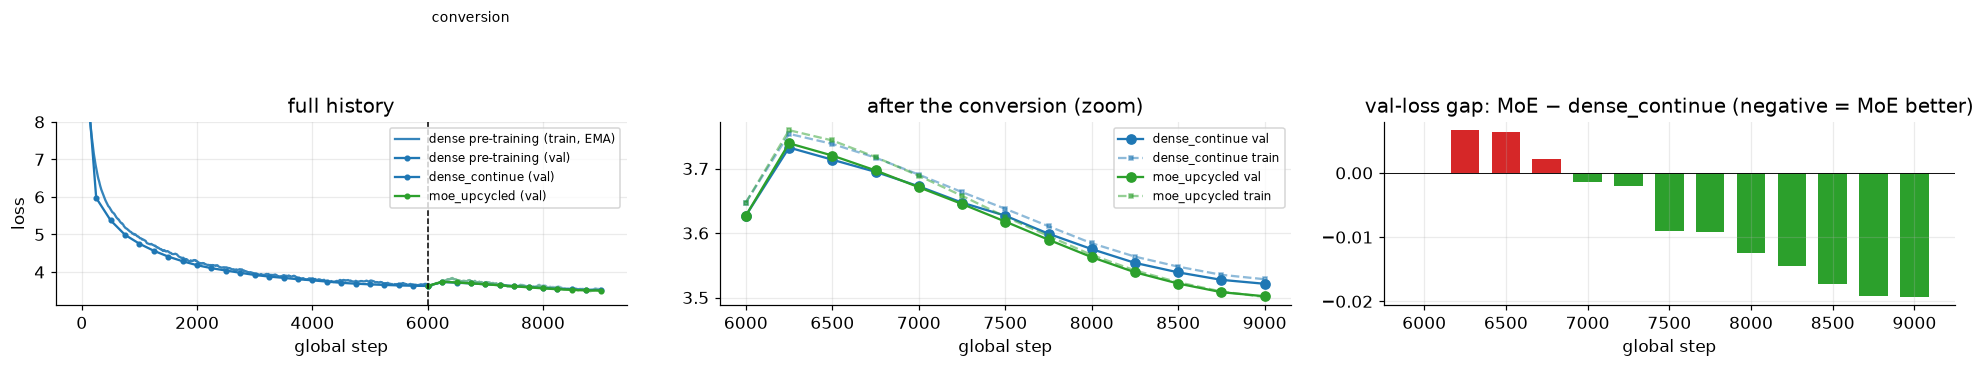

 global step  dense_continue val  moe_upcycled val  MoE − dense
        6000              3.6269            3.6269      -0.0000
        6250              3.7325            3.7391       0.0066
        6500              3.7137            3.7201       0.0064
        6750              3.6948            3.6970       0.0022
        7000              3.6724            3.6710      -0.0014
        7250              3.6471            3.6450      -0.0021
        7500              3.6269            3.6178      -0.0091
        7750              3.5989            3.5896      -0.0093
        8000              3.5750            3.5625      -0.0125
        8250              3.5537            3.5391      -0.0146
        8500              3.5390            3.5216      -0.0173
        8750              3.5274            3.5082      -0.0191
        9000              3.5213            3.5019      -0.0193


In [7]:
H_up, H_dc, H_dense = (
    load_history("moe_upcycled"),
    load_history("dense_continue"),
    load_history("dense"),
)
split = X.dense_steps

fig, axs = plt.subplots(1, 3, figsize=(18, 4.6))
ax = axs[0]
ax.plot(
    H_dense["step"],
    ema(H_dense["loss"], 0.1),
    color=color("dense"),
    alpha=0.9,
    label="dense pre-training (train, EMA)",
)
ax.plot(
    H_dense["eval_step"],
    H_dense["val_loss"],
    "o-",
    color=color("dense"),
    ms=3,
    label="dense pre-training (val)",
)
for lab, H in (("dense_continue", H_dc), ("moe_upcycled", H_up)):
    ax.plot(H["step"], ema(H["loss"], 0.1), color=color(lab), alpha=0.4)
    ax.plot(
        H["eval_step"],
        H["val_loss"],
        "o-",
        color=color(lab),
        ms=3,
        label=f"{lab} (val)",
    )
ax.axvline(split, color="k", ls="--", lw=1)
ax.text(split, ax.get_ylim()[1] * 0.97, " conversion", va="top", fontsize=9)
ax.set_title("full history")
ax.set_xlabel("global step")
ax.set_ylabel("loss")
ax.legend(fontsize=8)
ax.set_ylim(top=min(8, max(H_dense["loss"])))

ax = axs[1]
for lab, H in (("dense_continue", H_dc), ("moe_upcycled", H_up)):
    ax.plot(H["eval_step"], H["val_loss"], "o-", color=color(lab), label=f"{lab} val")
    ax.plot(
        H["eval_step"],
        H["train_loss"],
        "s--",
        color=color(lab),
        alpha=0.5,
        ms=3,
        label=f"{lab} train",
    )
ax.set_title("after the conversion (zoom)")
ax.set_xlabel("global step")
ax.legend(fontsize=8)

ax = axs[2]
dv = np.array(H_up["val_loss"]) - np.array(H_dc["val_loss"])
ax.bar(
    H_up["eval_step"],
    dv,
    width=max(1, X.eval_interval * 0.7),
    color=["#2ca02c" if v < 0 else "#d62728" for v in dv],
)
ax.axhline(0, color="k", lw=0.6)
ax.set_title("val-loss gap: MoE − dense_continue (negative = MoE better)")
ax.set_xlabel("global step")
plt.tight_layout()
savefig(fig, "03_upcycle_vs_dense_continue.png")
plt.show()

tab = pd.DataFrame(
    {
        "global step": H_up["eval_step"],
        "dense_continue val": H_dc["val_loss"],
        "moe_upcycled val": H_up["val_loss"],
    }
)
tab["MoE − dense"] = tab["moe_upcycled val"] - tab["dense_continue val"]
print(tab.round(4).to_string(index=False))

In [11]:
v0, v1 = H_up["val_loss"][0], H_up["val_loss"][-1]
print(f"dense model val loss before conversion  : {H_dense['final_val_loss']:.4f}")
print(
    f"MoE val loss at the moment of conversion: {v0:.4f}   (Δ = {v0 - H_dense['final_val_loss']:+.5f}  -> lossless)"
)
print(
    f"MoE val loss after {X.cont_steps} more steps    : {v1:.4f}   (improved by {v0 - v1:.4f} nats, ppl {math.exp(v0):.2f} -> {math.exp(v1):.2f})"
)
print(
    f"dense_continue val loss after the same  : {H_dc['final_val_loss']:.4f}   (improved by {H_dc['val_loss'][0] - H_dc['final_val_loss']:.4f})"
)
print(
    f"MoE vs dense control                    : {v1 - H_dc['final_val_loss']:+.4f} nats"
)
monotone = all(b <= a + 0.02 for a, b in zip(H_up["val_loss"], H_up["val_loss"][1:]))
print(
    "\nMoE kept reducing the loss after conversion:",
    v1 < v0,
    "| (near-)monotone over evals:",
    monotone,
)

dense model val loss before conversion  : 3.6269
MoE val loss at the moment of conversion: 3.6269   (Δ = -0.00000  -> lossless)
MoE val loss after 3000 more steps    : 3.5019   (improved by 0.1250 nats, ppl 37.60 -> 33.18)
dense_continue val loss after the same  : 3.5213   (improved by 0.1057)
MoE vs dense control                    : -0.0193 nats

MoE kept reducing the loss after conversion: True | (near-)monotone over evals: False


## 5. What changed inside the experts?

All experts start as *identical* copies. If they stay identical the MoE is just an expensive dense model.
Two diagnostics: cosine similarity between experts' weights (1 = still clones), and how far each expert has drifted from the original dense MLP.

  saved assets/03_expert_divergence.png


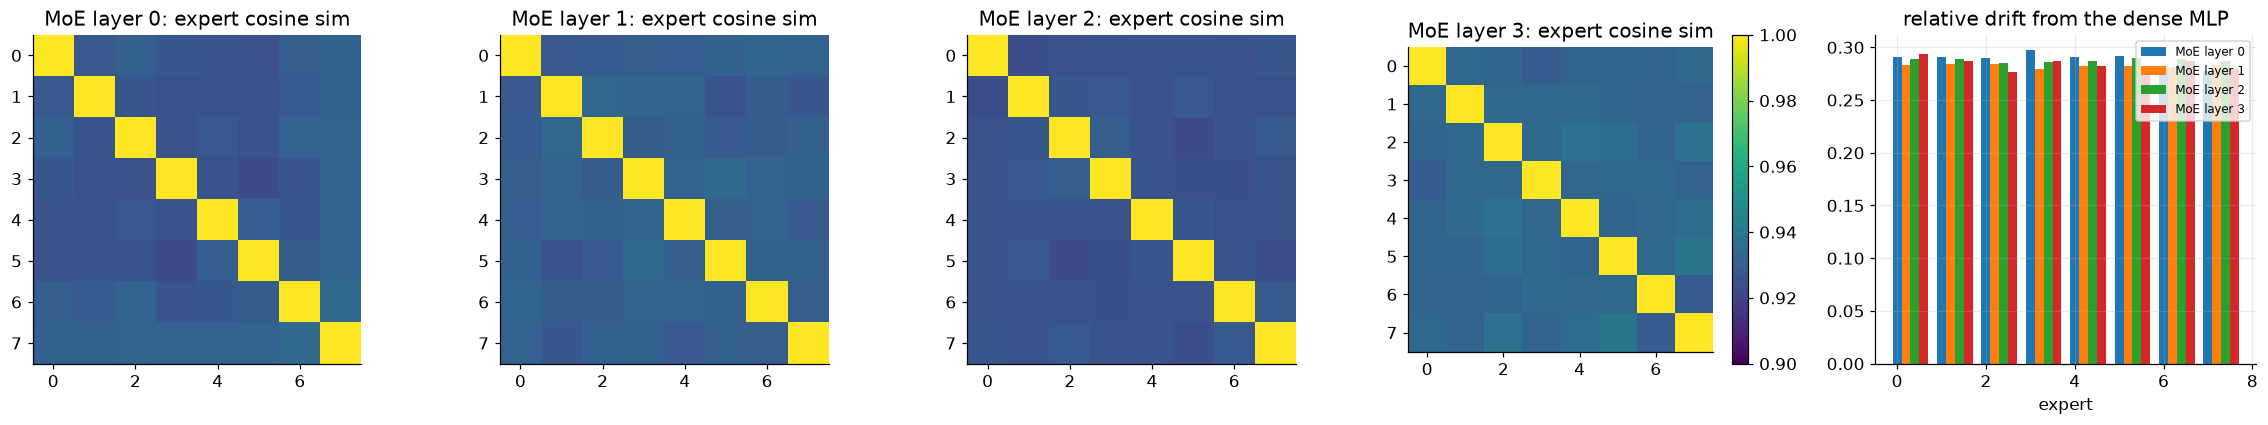

MoE layer 0: mean off-diagonal cosine similarity 0.928386 (min 0.923157)  | mean drift 0.2889
MoE layer 1: mean off-diagonal cosine similarity 0.930348 (min 0.926034)  | mean drift 0.2826
MoE layer 2: mean off-diagonal cosine similarity 0.926104 (min 0.923057)  | mean drift 0.2877
MoE layer 3: mean off-diagonal cosine similarity 0.933398 (min 0.928886)  | mean drift 0.2844


In [12]:
from moe.analysis import expert_drift, expert_similarity

sims = expert_similarity(up)
drift = expert_drift(up, load_model(dense_path, DEVICE))
fig, axs = plt.subplots(1, len(sims) + 1, figsize=(4.2 * (len(sims) + 1), 4))
for i, s in enumerate(sims):
    im = axs[i].imshow(s, vmin=min(0.9, s.min()), vmax=1)
    axs[i].set_title(f"MoE layer {i}: expert cosine sim")
    axs[i].grid(False)
plt.colorbar(im, ax=axs[len(sims) - 1])
for li, d in enumerate(drift):
    axs[-1].bar(np.arange(len(d)) + li * 0.2, d, width=0.2, label=f"MoE layer {li}")
axs[-1].set_title("relative drift from the dense MLP")
axs[-1].set_xlabel("expert")
axs[-1].legend(fontsize=8)
plt.tight_layout()
savefig(fig, "03_expert_divergence.png")
plt.show()
for i, s in enumerate(sims):
    off = s[~np.eye(len(s), dtype=bool)]
    print(
        f"MoE layer {i}: mean off-diagonal cosine similarity {off.mean():.6f} (min {off.min():.6f})  | mean drift {drift[i].mean():.4f}"
    )

## 6. Routing after conversion

  saved assets/03_upcycled_routing.png


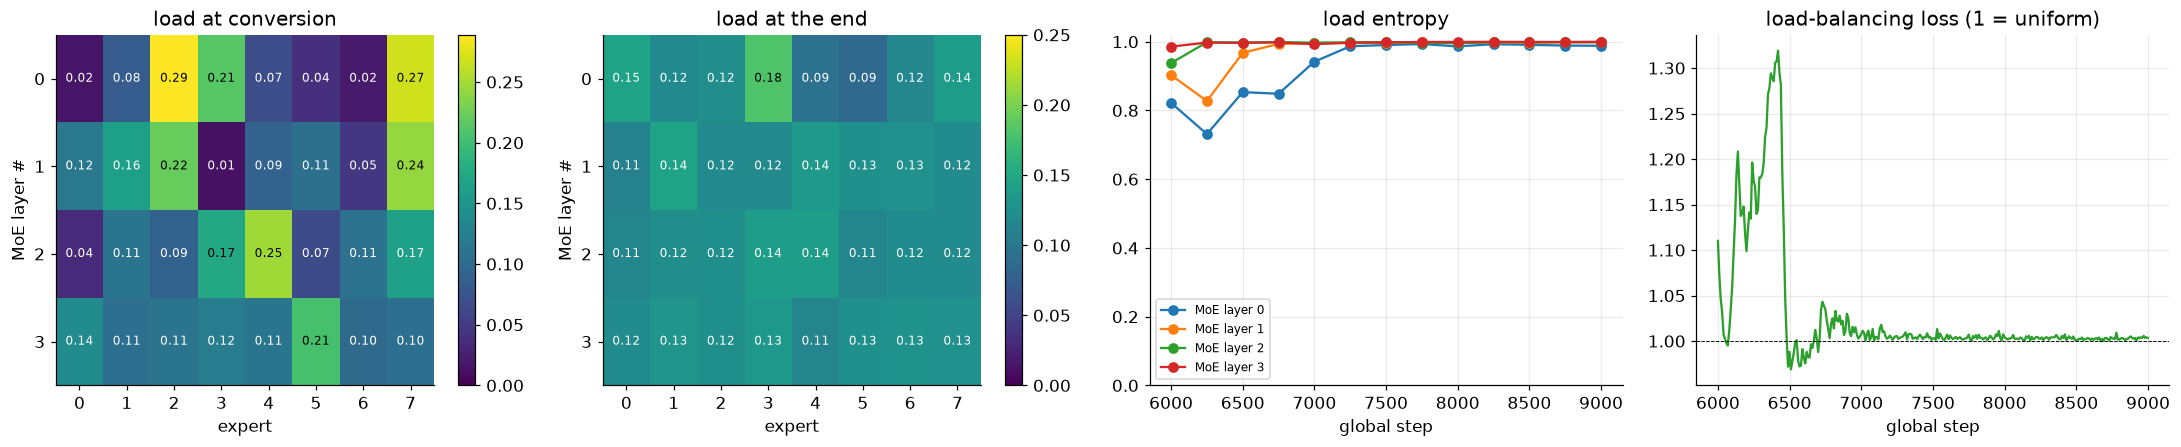

dead experts over time: [0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [13]:
load = np.array(H_up["load"])
E = load.shape[2]
fig, axs = plt.subplots(1, 4, figsize=(20, 4.2))
im = heatmap_load(axs[0], load[0], "load at conversion")
plt.colorbar(im, ax=axs[0])
im = heatmap_load(axs[1], load[-1], "load at the end")
plt.colorbar(im, ax=axs[1])
ent = np.array(H_up["load_entropy"])
for li in range(ent.shape[1]):
    axs[2].plot(H_up["eval_step"], ent[:, li], "o-", label=f"MoE layer {li}")
axs[2].set_title("load entropy")
axs[2].set_xlabel("global step")
axs[2].legend(fontsize=8)
axs[2].set_ylim(0, 1.02)
axs[3].plot(H_up["step"], H_up["lb"], color="#2ca02c")
axs[3].axhline(1, color="k", ls="--", lw=0.6)
axs[3].set_title("load-balancing loss (1 = uniform)")
axs[3].set_xlabel("global step")
plt.tight_layout()
savefig(fig, "03_upcycled_routing.png")
plt.show()
print("dead experts over time:", H_up["dead_experts"])

## 7. (Optional) Ablations

Off by default (each is a full continuation run). Enable with `MOE_ABLATIONS=1` (always on in the smoke test).
All of them start from the same dense checkpoint and see the same batches.

running ablations: True


[abl_noise0.02] 110.02M params (59.63M active/token) | 3000 steps x 16,384 tok = 49.2M tokens | lr 0.0003 | amp=bf16 | device=cuda:1
  step  6000 | train 3.6473 | val 3.6270 (ppl 37.6) | load-entropy 0.858 | MaxVio 1.28 | dead 3
  step  6250 | train 3.7582 | val 3.7372 (ppl 42.0) | load-entropy 0.874 | MaxVio 1.55 | dead 2
  step  6500 | train 3.7440 | val 3.7198 (ppl 41.3) | load-entropy 0.966 | MaxVio 0.59 | dead 1
  step  6750 | train 3.7190 | val 3.6983 (ppl 40.4) | load-entropy 0.982 | MaxVio 0.33 | dead 0
  step  7000 | train 3.6889 | val 3.6717 (ppl 39.3) | load-entropy 0.987 | MaxVio 0.40 | dead 0
  step  7250 | train 3.6561 | val 3.6426 (ppl 38.2) | load-entropy 0.995 | MaxVio 0.25 | dead 0
  step  7500 | train 3.6260 | val 3.6182 (ppl 37.3) | load-entropy 0.991 | MaxVio 0.33 | dead 0
  step  7750 | train 3.5949 | val 3.5883 (ppl 36.2) | load-entropy 0.996 | MaxVio 0.21 | dead 0
  step  8000 | train 3.5654 | val 3.5618 (ppl 35.2) | load-entropy 0.997 | MaxVio 0.12 | dead 0
  s

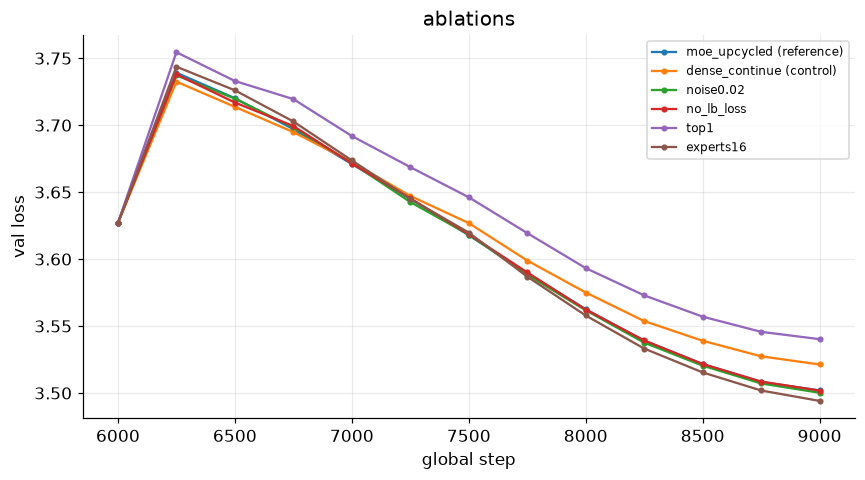

In [14]:
RUN_ABLATIONS = is_smoke() or os.environ.get("MOE_ABLATIONS", "1") == "1"
print("running ablations:", RUN_ABLATIONS)
if RUN_ABLATIONS:
    variants = {
        "noise0.02": {"up": {"expert_noise": 0.02}},
        "no_lb_loss": {"tc": {"lb_coef": 0.0}},
        "top1": {"up": {"top_k": 1}},
        "experts16": {"up": {"n_experts": 2 * X.n_experts}},
    }
    abl = {"moe_upcycled (reference)": H_up, "dense_continue (control)": H_dc}
    for name, v in variants.items():
        kw = {
            "n_experts": X.n_experts,
            "top_k": X.top_k,
            "moe_every": X.moe_every,
            "seed": X.seed,
        }
        kw.update(v.get("up", {}))
        m = upcycle(load_model(dense_path, DEVICE), **kw)
        t = train_config(
            X,
            f"abl_{name}",
            f"abl_{name}",
            X.cont_steps,
            X.cont_lr,
            X.cont_warmup,
            step_offset=X.dense_steps,
            device=DEVICE,
            **v.get("tc", {}),
        )
        _, h = train(
            m,
            data,
            t,
            experiment="session14_ablations",
            aim_repo=aim_repo(),
            extra_hparams={"ablation": name, **v.get("up", {})},
        )
        abl[name] = h
    rows = {
        k: {
            "val @ conversion": h["val_loss"][0],
            "final val": h["final_val_loss"],
            "Δ vs dense_continue": h["final_val_loss"] - H_dc["final_val_loss"],
        }
        for k, h in abl.items()
    }
    print(pd.DataFrame(rows).T.round(4).to_string())
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for k, h in abl.items():
        ax.plot(h["eval_step"], h["val_loss"], "o-", ms=3, label=k)
    ax.set_xlabel("global step")
    ax.set_ylabel("val loss")
    ax.legend(fontsize=8)
    ax.set_title("ablations")
    plt.tight_layout()
    savefig(fig, "03_ablations.png")
    plt.show()